In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [3]:
import pmdarima as pm

In [4]:
df = pd.read_csv('sp500sub.csv', index_col = 'Date', parse_dates=True)

In [5]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,Name
Date,,,,,,,
2010-01-04,9.22,9.51,9.17,9.50,9.50,1865400.0,INCY
2010-01-05,9.51,10.29,9.45,10.27,10.27,7608900.0,INCY
2010-01-06,10.38,11.09,10.35,11.00,11.00,8046700.0,INCY
2010-01-07,11.00,11.06,10.62,10.82,10.82,3680300.0,INCY
2010-01-08,10.82,11.00,10.75,10.94,10.94,1529300.0,INCY


## this doesnt look at log price approach - may be that could be better - but should be checked

In [5]:
goog = df[df['Name']=='GOOG']['Close']

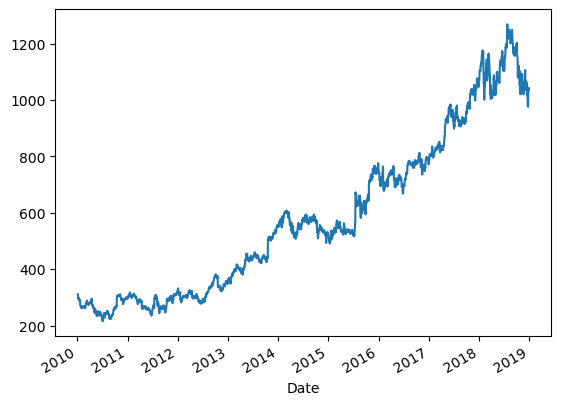

In [6]:
goog.plot();

In [30]:
Ntest = 30
train = goog.iloc[:-Ntest]
test = goog.iloc[-Ntest:]

In [13]:
model = pm.auto_arima(train,
                      error_action = 'ignore', # skips the problematic models which is mathematically not stable, can be set to 'trace' to provide more feedback
                      trace = True,
                      suppress_warnings = True,
                      maxiter = 10, # with each specific combination p,d,q, it tries to find the best coeefieicnets weights for that specific model by running the gradient descent 10 times , or 10 steps
                      # doesnt run gradient descent exactly, uses other algo lbgfs
                      seasonal = False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16270.771, Time=0.98 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16270.383, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16269.726, Time=0.27 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16269.492, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16271.123, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16268.077, Time=0.67 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=16267.935, Time=0.79 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=16268.277, Time=0.60 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=16266.968, Time=0.72 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=16264.983, Time=0.98 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=16266.925, Time=1.12 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=16268.907, Time=1.58 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=16265.470, Time=0.34 sec

Best model:  ARIMA(3,1,0)(0,0,0)[0] intercept
Total fit time: 8.617 seconds


In [14]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2233
Model:               SARIMAX(3, 1, 0)   Log Likelihood               -8127.491
Date:                Mon, 23 Mar 2026   AIC                          16264.983
Time:                        14:32:21   BIC                          16293.536
Sample:                             0   HQIC                         16275.409
                               - 2233                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3104      0.198      1.571      0.116      -0.077       0.698
ar.L1          0.0378      0.012      3.152      0.002       0.014       0.061
ar.L2         -0.0410      0.013     -3.241      0.001      -0.066      -0.016
ar.L3          0.0488      0.012      4.031      0.000       0.025       0.073
sigma2        85.1623      1.033     82.421      0.000      83.137      87.187
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             11790.07
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               6.78   Skew:                             0.09
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [23]:
''' differencing makes sense , since returns are stationary, even when 1st diff is not exactly returns'''

' differencing makes sense , since returns are stationary, even when 1st diff is not exactly returns'

In [22]:
test1 = df[df['Name']=='GOOG'][['Close']]
test1['Diff'] = test1['Close'].diff()
from statsmodels.tsa.stattools import adfuller
adfuller(test1['Diff'].dropna())

(np.float64(-8.837168614178452),
 np.float64(1.7067429223205775e-14),
 27,
 2234,
 {'1%': np.float64(-3.4332805415364724),
  '5%': np.float64(-2.8628346299364282),
  '10%': np.float64(-2.5674591931002038)},
 np.float64(16418.1844750972))

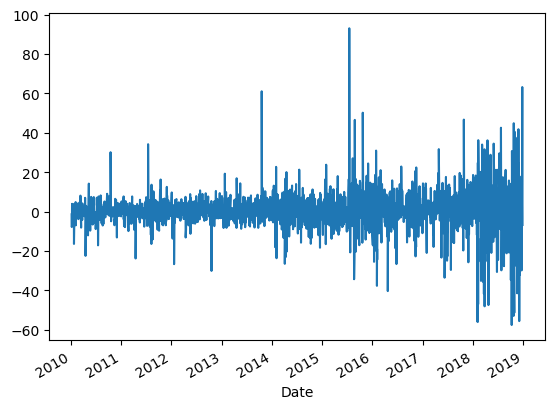

In [25]:
test1['Diff'].plot();

In [26]:
''' best model it found out was (3,1,0).
AR component has order 3'''

' best model it found out was (3,1,0).\nAR component has order 3'

In [27]:
model.get_params()

{'maxiter': 10,
 'method': 'lbfgs',
 'order': (3, 1, 0),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': True}

In [13]:
def plot_result(model, fulldata, train, test):
    params = model.get_params()
    d = params['order'][1]

    train_pred = model.predict_in_sample(start = d, end = -1) # setting start=d since differencing would make the 1st 2 values nans
    test_pred , confint = model.predict(n_periods= Ntest, return_conf_int = True)

    fig, ax = plt.subplots(figsize = (10,5))
    ax.plot(fulldata.index, fulldata, label ='data')
    ax.plot(train.index[d:], train_pred, label = 'fitted')
    ax.plot(test.index, test_pred, label = 'forecast')
    ax.fill_between(test.index, confint[:,0], confint[:,1], color ='red', alpha = 0.3)
    ax.legend();

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


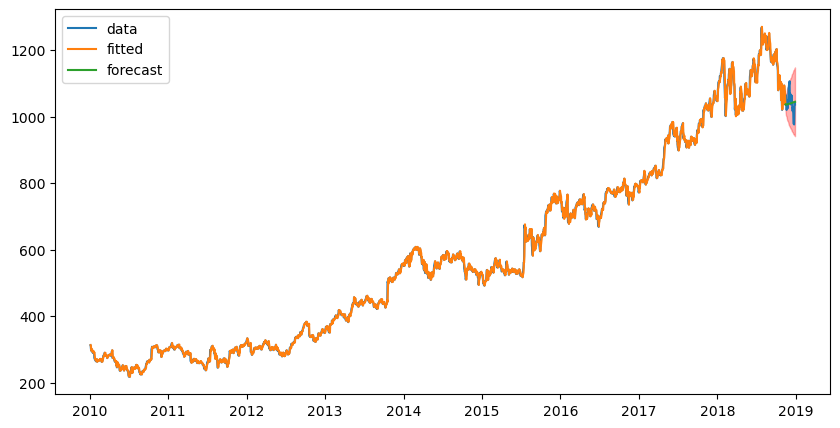

In [31]:
plot_result(model, goog, train, test)

In [12]:
def plot_test(model, test):
    # params = model.get_params()
    # d = params['order'][1]

    # train_pred = model.predict_in_sample(start = d, end = -1) # setting start=d since differencing would make the 1st 2 values nans
    test_pred , confint = model.predict(n_periods= Ntest, return_conf_int = True)

    fig, ax = plt.subplots(figsize = (10,5))
    ax.plot(test.index, test, label ='data')
    # ax.plot(train.index[d:], train_pred, label = 'fitted')
    ax.plot(test.index, test_pred, label = 'forecast')
    ax.fill_between(test.index, confint[:,0], confint[:,1], color ='red', alpha = 0.3)
    ax.legend();

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


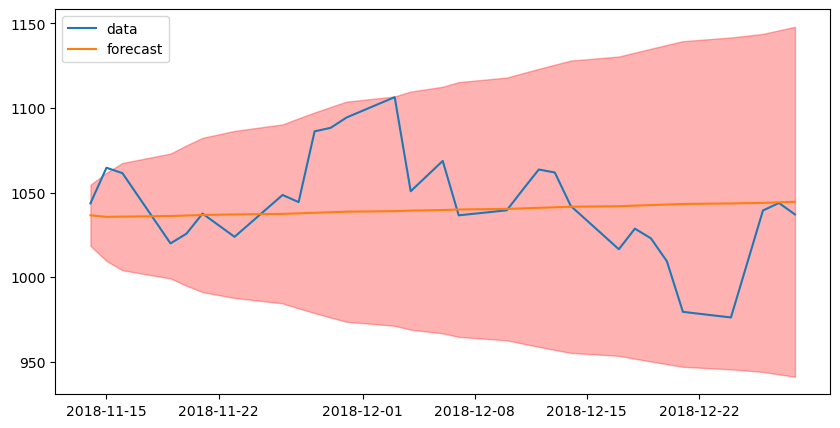

In [33]:
plot_test(model, test);

In [35]:
''' this is good and capturing the average quite well'''

' this is good and capturing the average quite well'

In [21]:
def rmse(t,y):
    return np.sqrt(np.mean((t-y)**2))

In [47]:
print("RMSE ARIMA:", rmse(test.to_numpy(), model.predict(Ntest)))
print("RMSE NAIVE:", rmse(test, train.iloc[-1])) ## last known value in train is the naive forecast - which would be constant for the test period

RMSE ARIMA: 30.436602015599053
RMSE NAIVE: 30.029502477261467


C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [1]:
''' it is the naive forecast which is outperforming yet again'''

' it is the naive forecast which is outperforming yet again'

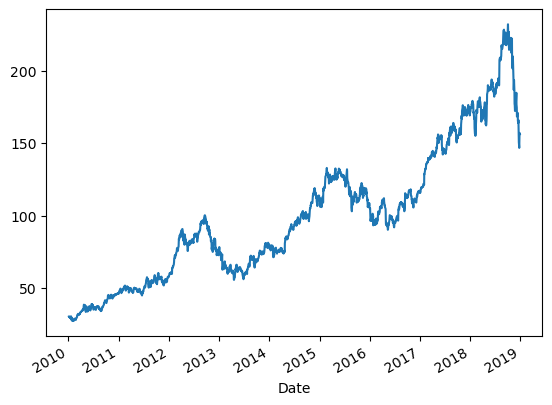

In [6]:
aapl = df[df['Name']=='AAPL']['Close']
aapl.plot();

In [7]:
''' arima follows trends, we can see that there is a sharp drop for 2018, arima by intuition should find it difficult
to predict ths'''

' arima follows trends, we can see that there is a sharp drop for 2018, arima by intuition should find it difficult\nto predict ths'

In [8]:
Ntest = 30
train = aapl.iloc[:-Ntest]
test = aapl.iloc[-Ntest:]

In [9]:
model = pm.auto_arima(train,
                      error_action = 'ignore', # skips the problematic models which is mathematically not stable, can be set to 'trace' to provide more feedback
                      trace = True,
                      suppress_warnings = True,
                      maxiter = 10, # with each specific combination p,d,q, it tries to find the best coeefieicnets weights for that specific model by running the gradient descent 10 times , or 10 steps
                      # doesnt run gradient descent exactly, uses other algo lbgfs
                      seasonal = False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=8570.296, Time=1.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8575.329, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8574.709, Time=0.28 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8574.392, Time=0.28 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8577.622, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=8571.650, Time=0.56 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=8571.332, Time=0.75 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=8572.500, Time=0.91 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=8572.527, Time=0.96 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=8574.574, Time=0.53 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=8570.852, Time=0.86 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=8570.880, Time=0.93 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=8579.289, Time=1.02 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=8572.973, Time=0.41 sec

Best model:  ARIMA(2,1,2)(0,0,0)

In [10]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2233
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -4279.148
Date:                Mon, 23 Mar 2026   AIC                           8570.296
Time:                        16:36:40   BIC                           8604.560
Sample:                             0   HQIC                          8582.808
                               - 2233                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0803      0.042      1.896      0.058      -0.003       0.163
ar.L1          0.3755      0.165      2.279      0.023       0.053       0.699
ar.L2         -0.4239      0.176     -2.407      0.016      -0.769      -0.079
ma.L1         -0.3433      0.172     -2.002      0.045      -0.679      -0.007
ma.L2          0.3579      0.183      1.958      0.050      -0.000       0.716
sigma2         2.7182      0.039     69.453      0.000       2.642       2.795
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              6223.04
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               4.23   Skew:                            -0.40
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [14]:
''' earlier in goog model, we had p=3 and q=0'''

' earlier in goog model, we had p=3 and q=0'

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


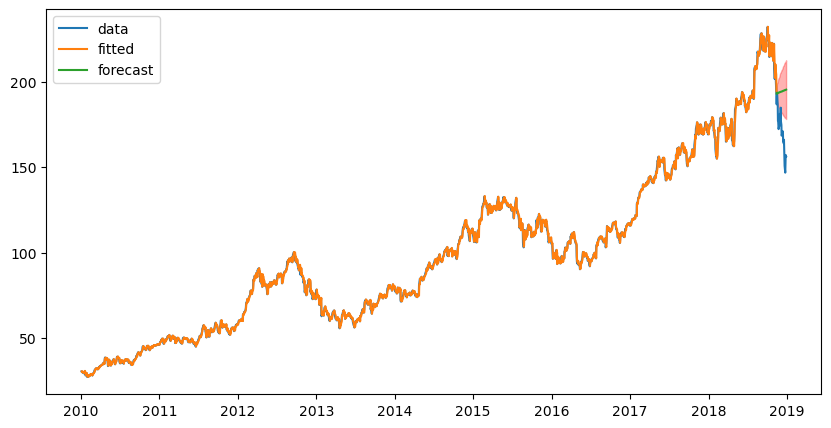

In [15]:
plot_result(model, aapl, train, test)

In [18]:
'''look at the test data, model just want to carry out the existing trend. this is how most ML models would do'''

'look at the test data, model just want to carry out the existing trend. this is how most ML models would do'

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


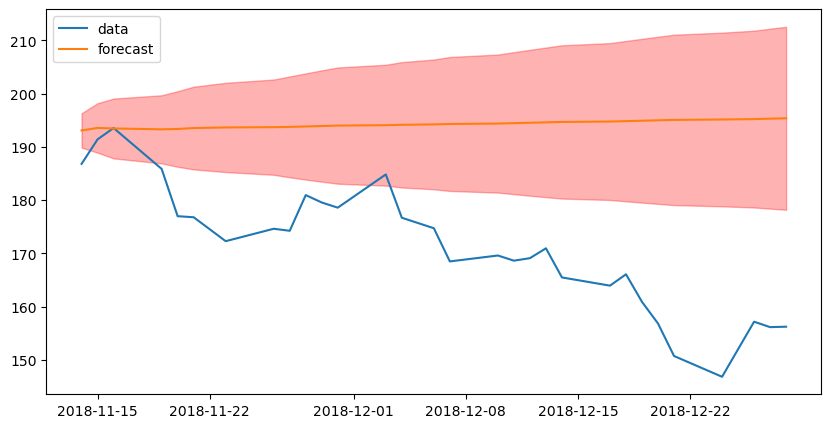

In [17]:
plot_test(model, test);

In [19]:
''' for 1st few days, the true values stay inside the confidence bounds'''

' for 1st few days, the true values stay inside the confidence bounds'

In [22]:
print("RMSE ARIMA:", rmse(test.to_numpy(), model.predict(Ntest)))
print("RMSE NAIVE:", rmse(test, train.iloc[-1])) ## last known value in train is the naive forecast - which would be constant for the test period

RMSE ARIMA: 26.094954710370793
RMSE NAIVE: 24.02712058667382


C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [23]:
''' naive forecast performs better than arima'''

' naive forecast performs better than arima'

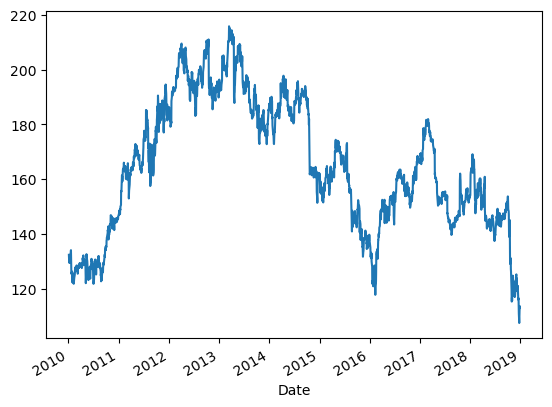

In [24]:
ibm = df[df['Name']=='IBM']['Close']
ibm.plot();

In [25]:
Ntest = 30
train = ibm.iloc[:-Ntest]
test = ibm.iloc[-Ntest:]

In [26]:
model = pm.auto_arima(train,
                      error_action = 'ignore', # skips the problematic models which is mathematically not stable, can be set to 'trace' to provide more feedback
                      trace = True,
                      suppress_warnings = True,
                      maxiter = 10, # with each specific combination p,d,q, it tries to find the best coeefieicnets weights for that specific model by running the gradient descent 10 times , or 10 steps
                      # doesnt run gradient descent exactly, uses other algo lbgfs
                      seasonal = False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=9442.954, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9436.082, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9437.603, Time=0.21 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9437.589, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9434.097, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9439.637, Time=0.55 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.079 seconds


In [27]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2233
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4716.049
Date:                Mon, 23 Mar 2026   AIC                           9434.097
Time:                        16:44:19   BIC                           9439.808
Sample:                             0   HQIC                          9436.183
                               - 2233                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         4.0067      0.055     72.559      0.000       3.898       4.115
===================================================================================
Ljung-Box (L1) (Q):                   0.48   Jarque-Bera (JB):              5352.76
Prob(Q):                              0.49   Prob(JB):                         0.00
Heteroskedasticity (H):               0.85   Skew:                            -0.77
Prob(H) (two-sided):                  0.03   Kurtosis:                        10.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [31]:
''' best fitting model is a random walk, i.e, arima(0,1,0). why is arima(0,1,0) a random walk?
 - diff is d =1 in 0,1,0, which means that after diff once, data becomes stationary 
 - stationarity means that y(t)-y(t-1) = error, which is equivalent to writing y(t) = y(t-1) + e, 
 - y(t) = y(t-1) + e, which means the best predictor of tomorrow is today which is exactly random walk'''

' best fitting model is a random walk, i.e, arima(0,1,0). why is arima(0,1,0) a random walk?\n - diff is d =1 in 0,1,0, which means that after diff once, data becomes stationary \n - stationarity means that y(t)-y(t-1) = error, which is equivalent to writing y(t) = y(t-1) + e, \n - y(t) = y(t-1) + e, which means the best predictor of tomorrow is today which is exactly random walk'

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


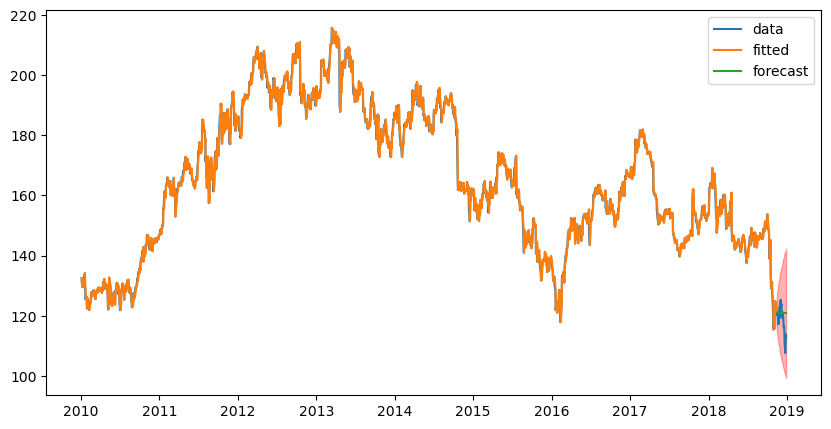

In [28]:
plot_result(model, ibm, train, test)

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


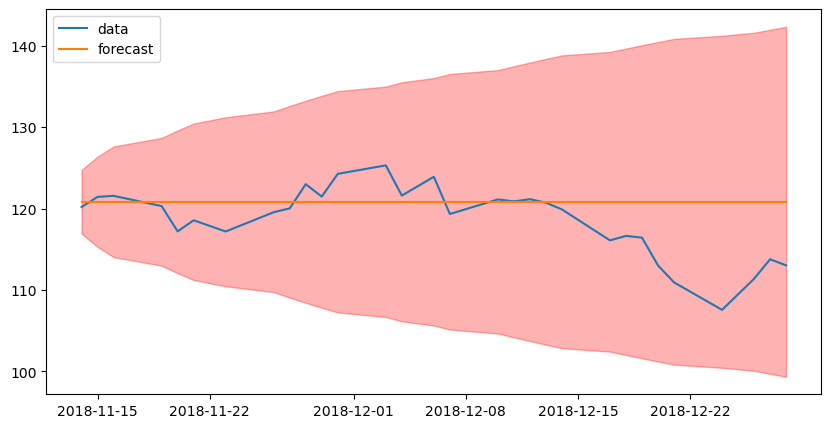

In [29]:

plot_test(model, test);


In [30]:

print("RMSE ARIMA:", rmse(test.to_numpy(), model.predict(Ntest)))
print("RMSE NAIVE:", rmse(test, train.iloc[-1])) ## last known value in train is the naive forecast - which would be constant for the test period

RMSE ARIMA: 4.763157130051095
RMSE NAIVE: 4.763157130051095


C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [32]:
''' since arima is random walk, it is same as naive forecast only'''

' since arima is random walk, it is same as naive forecast only'

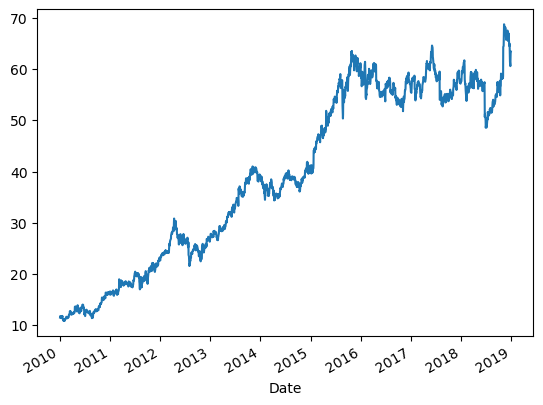

In [33]:
sbux = df[df['Name']=='SBUX']['Close']
sbux.plot();

In [34]:

Ntest = 30
train = sbux.iloc[:-Ntest]
test = sbux.iloc[-Ntest:]


In [35]:
	
model = pm.auto_arima(train,
                      error_action = 'ignore', # skips the problematic models which is mathematically not stable, can be set to 'trace' to provide more feedback
                      trace = True,
                      suppress_warnings = True,
                      maxiter = 10, # with each specific combination p,d,q, it tries to find the best coeefieicnets weights for that specific model by running the gradient descent 10 times , or 10 steps
                      # doesnt run gradient descent exactly, uses other algo lbgfs
                      seasonal = False)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3858.919, Time=0.99 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3851.895, Time=0.62 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3853.862, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3853.860, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3854.154, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3855.861, Time=0.35 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 2.672 seconds


In [36]:
''' AGAIN ITS RANDOM WALK but with intercept/drift'''

' AGAIN ITS RANDOM WALK'

In [41]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2233
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1923.948
Date:                Mon, 23 Mar 2026   AIC                           3851.895
Time:                        16:56:42   BIC                           3863.317
Sample:                             0   HQIC                          3856.066
                               - 2233                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0250      0.012      2.048      0.041       0.001       0.049
sigma2         0.3283      0.003     94.371      0.000       0.321       0.335
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):             18901.16
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               3.80   Skew:                            -0.51
Prob(H) (two-sided):                  0.00   Kurtosis:                        17.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [43]:
''' look at the summary and see there is intercept or drift with non zero values '''
''' how to interpret this intercept or drift?
- naive forecast would be y(t) = y(t-1) + error
- this model is y(t) = y(t-1) + error + intercept = y(t) = y(t-1) + error + 0.0250 
intercept being positive means that the stock prices changes by 0.0250 on a average at each time step'''

' how to interpret this intercept or drift?\n- naive forecast would be y(t) = y(t-1) + error\n- this model is y(t) = y(t-1) + error + intercept = y(t) = y(t-1) + error + 0.0250 \nintercept being positive means that the stock prices changes by 0.0250 on a average at each time step'

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


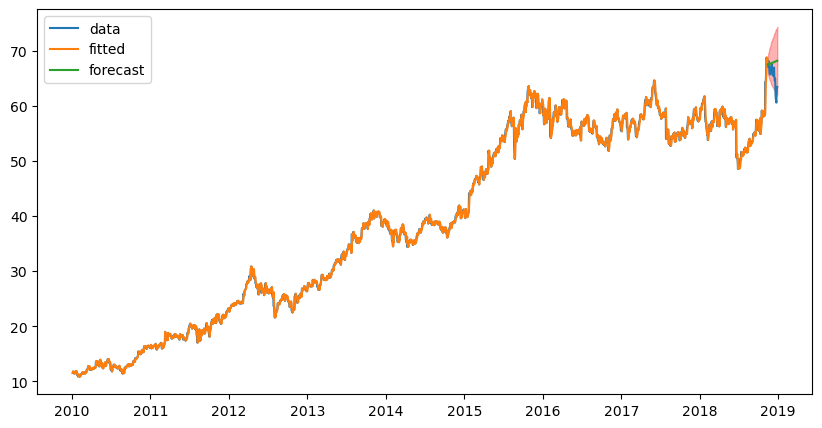

In [37]:
plot_result(model, sbux, train, test)

C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


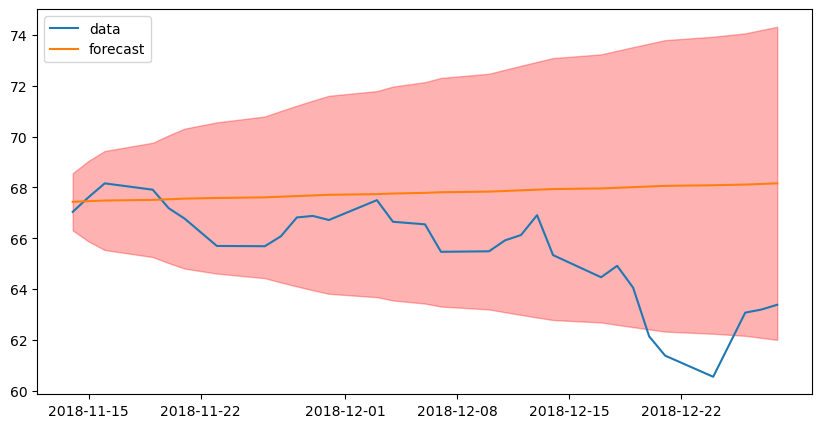

In [38]:
plot_test(model, test);

In [39]:
print("RMSE ARIMA:", rmse(test.to_numpy(), model.predict(Ntest)))
print("RMSE NAIVE:", rmse(test, train.iloc[-1])) ## last known value in train is the naive forecast - which would be constant for the test period

RMSE ARIMA: 3.094903479339405
RMSE NAIVE: 2.6889385763409135


C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [44]:
''' naive forecast wins again. arima model was not exactly naive but naive + some intercept'''
'''naive forecat wins since in our model it detected a positive drift/intercept - hence if u notice, the prediction is not straight line
but slightly moving upwards, but since in reality the prices went down, the naive forecast won since it has no assumed intercept that too +ve'''

'naive forecat wins since in our model it detected a positive drift/intercept - hence if u notice, the prediction is not straight line\nbut slightly moving upwards, but since in reality the prices went down, the naive forecast won since it has no assumed intercept that too +ve'